LFC columns: ['log2FoldChange_rep1', 'log2FoldChange_rep2', 'log2FoldChange_rep3']
SE columns: ['lfcSE_rep1', 'lfcSE_rep2', 'lfcSE_rep3']


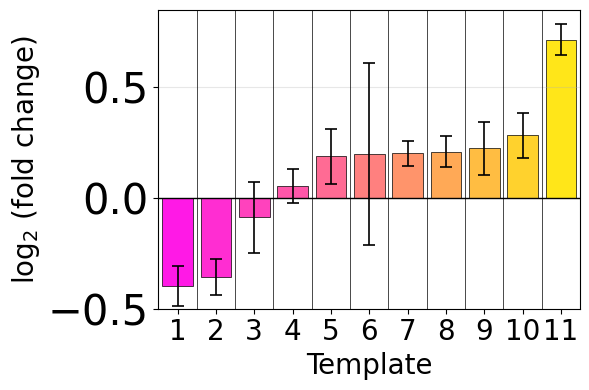

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Load data
df1 = pd.read_csv('/../../Data/Figure_5/sequencing_data_all.csv')

# Identify columns for reps 1-3
lfc_cols = sorted([c for c in df1.columns if c.startswith('log2FoldChange_rep') 
                   and c[-1] in ['1', '2', '3']])
se_cols = sorted([c for c in df1.columns if c.startswith('lfcSE_rep') 
                  and c[-1] in ['1', '2', '3']])

print(f"LFC columns: {lfc_cols}")
print(f"SE columns: {se_cols}")

# Extract data
lfc_data = df1[lfc_cols].values
se_data = df1[se_cols].values

# Calculate inverse-variance weights
weights = 1 / (se_data ** 2)

# Weighted mean LFC
df1['weighted_log2FC'] = np.nansum(weights * lfc_data, axis=1) / np.nansum(weights, axis=1)

# SE of the weighted mean = 1 / sqrt(sum of weights)
df1['weighted_SE'] = 1 / np.sqrt(np.nansum(weights, axis=1))

# Define row order
row_order = [
    'syn_LEA_1',
    'At2g46140_tile7',
    'TgL_8x',
    'Os_LEA_or3__Kappa_up_2_',
    'CAHS_68135_tile4',
    'A0A438HAK2',
    'Asyn_isoform_5',
    'A0A1U8F7A1',
    'Os_LEA_or6',
    'Os_LEA_or4',
    'A0A4D6M434',
]

# Get weighted_log2FC and weighted_SE for each row in row_order
plot_data = []
for name in row_order:
    wt_id = f'original_sequence_-_{name}'
    match = df1[df1['Sequence_ID'] == wt_id]
    if len(match) > 0:
        avg = match['weighted_log2FC'].values[0]
        se  = match['weighted_SE'].values[0]
        plot_data.append({'name': name, 'weighted_log2FC': avg, 'weighted_SE': se})

plot_df = pd.DataFrame(plot_data)

# Sort by weighted_log2FC ascending
plot_df = plot_df.sort_values('weighted_log2FC', ascending=True).reset_index(drop=True)

# Truncated spring colormap
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    return LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n)))

truncated_spring = truncate_colormap(plt.cm.spring, 0.10, 0.90)

colors = [truncated_spring(i / (len(plot_df) - 1)) for i in range(len(plot_df))]

fig, ax = plt.subplots(figsize=(6, 4))

# Vertical bar chart with error bars
ax.bar(
    range(len(plot_df)),
    plot_df['weighted_log2FC'],
    yerr=plot_df['weighted_SE'],
    color=colors,
    edgecolor='black',
    linewidth=0.5,
    error_kw=dict(ecolor='black', elinewidth=1.2, capsize=4, capthick=1.2)
)

# Reference line and gridlines
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
for i in range(len(plot_df) + 1):
    ax.axvline(x=i - 0.5, color='black', linestyle='-', linewidth=0.5)

ax.set_ylabel('log$_2$ (fold change)', fontsize=20)
ax.set_xlabel('')
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels([str(i+1) for i in range(len(plot_df))], fontsize=20)
ax.set_xlabel('Template', fontsize=20)
ax.set_xlim(-0.5, len(plot_df) - 0.5)
ax.set_ylim(-0.5, None)
ax.tick_params(axis='y', labelsize=30)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
#plt.rcParams['svg.fonttype'] = 'none'
#plt.savefig('log2fc_barplot_weighted.svg', format='svg', bbox_inches='tight')
plt.show()